# 🗺️ Clase 2 — Proyectos de IA: del problema a la solución

En esta clase vas a entender **cómo se estructura un proyecto de IA de principio a fin**: 
las etapas que recorre, cuánto tiempo lleva cada una, y qué roles participan.

### ¿Qué vamos a cubrir?

| Sección | Concepto |
|---|---|
| 1 | El ciclo de vida de un proyecto de IA |
| 2 | Las 7 etapas en detalle |
| 3 | ¿Dónde se gasta el tiempo? |
| 4 | Roles en un equipo de IA |
| 5 | Análisis de 5 casos de uso reales |
| 6 | Tu primera predicción con código |
| 7 | Ejercicio evaluable: ficha de caso |

> **Ningún proyecto de IA empieza 'haciendo el modelo'. Empieza entendiendo el problema.**

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
random.seed(42)

print("✅ Entorno listo.")

✅ Entorno listo.


---
## 1. El ciclo de vida de un proyecto de IA

Un proyecto de IA **no es solo entrenar un modelo**. Tiene 7 etapas bien definidas:

```
1. Definir el problema  →  ¿Qué queremos resolver?
2. Recopilar datos      →  Obtener la materia prima
3. Explorar y limpiar   →  Entender y preparar los datos
4. Crear features       →  Transformar datos en entradas útiles
5. Entrenar modelos     →  El modelo aprende de los datos
6. Evaluar              →  ¿Funciona? ¿Es suficientemente bueno?
7. Desplegar            →  Ponerlo en producción
```

> 💡 **Regla clave:** las etapas 1–4 suelen consumir el **70-80% del tiempo** de un proyecto real.

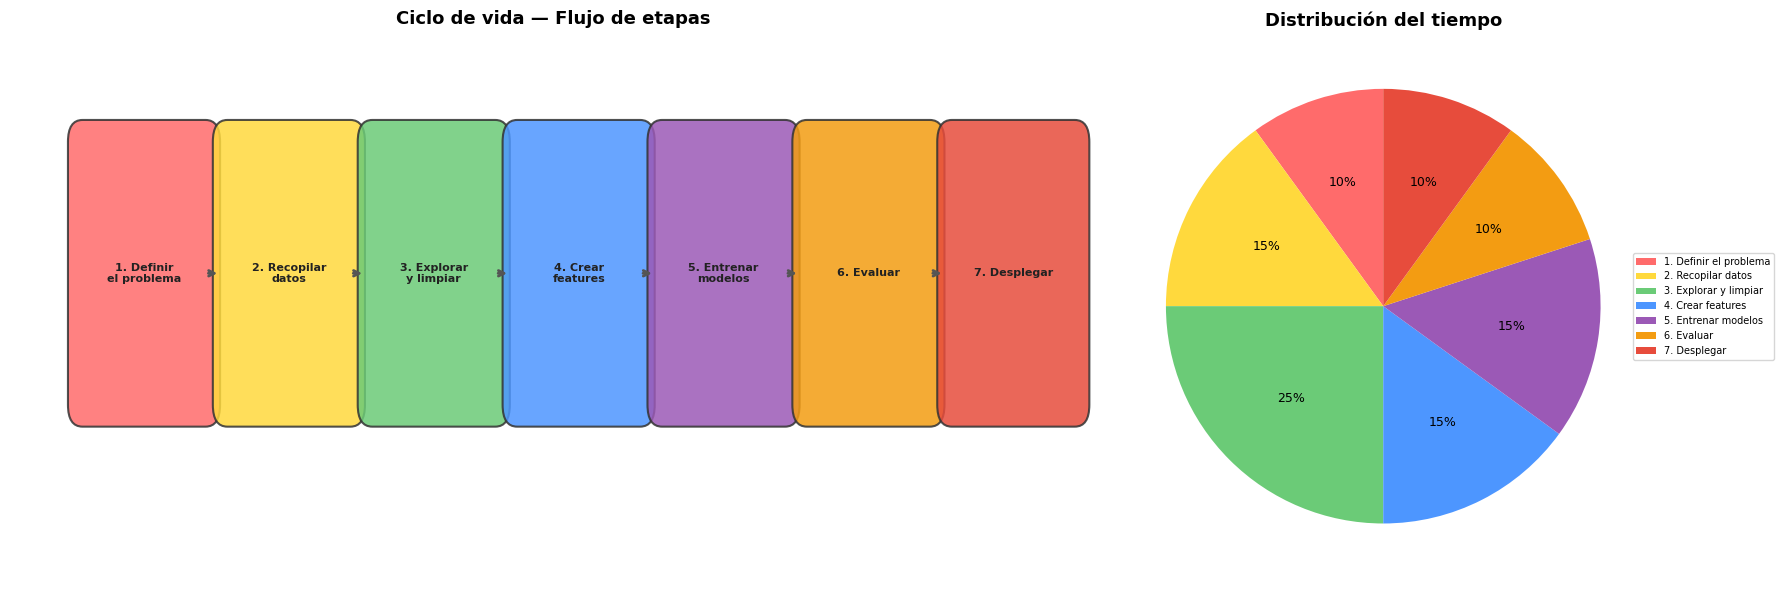


📊 Las etapas de DATOS (2-4) consumen ~55% del tiempo total de un proyecto.
   'Entrenar el modelo' es solo ~15%. La preparación es la clave.


In [5]:
# Visualización del ciclo de vida

etapas = [
    {"nombre": "1. Definir\nel problema",     "color": "#ff6b6b", "pct": 10},
    {"nombre": "2. Recopilar\ndatos",         "color": "#ffd93d", "pct": 15},
    {"nombre": "3. Explorar\ny limpiar",      "color": "#6bcb77", "pct": 25},
    {"nombre": "4. Crear\nfeatures",          "color": "#4d96ff", "pct": 15},
    {"nombre": "5. Entrenar\nmodelos",        "color": "#9b59b6", "pct": 15},
    {"nombre": "6. Evaluar",                   "color": "#f39c12", "pct": 10},
    {"nombre": "7. Desplegar",                 "color": "#e74c3c", "pct": 10},
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [2, 1]})

# Diagrama de flujo
ax1.set_xlim(-0.5, 7)
ax1.set_ylim(-0.5, 2)
ax1.axis("off")
ax1.set_title("Ciclo de vida — Flujo de etapas", fontsize=13, fontweight="bold")

for i, e in enumerate(etapas):
    rect = mpatches.FancyBboxPatch(
        (i, 0.3), 0.85, 1.2,
        boxstyle="round,pad=0.1",
        facecolor=e["color"], edgecolor="#333", linewidth=1.5, alpha=0.85
    )
    ax1.add_patch(rect)
    ax1.text(i + 0.425, 0.9, e["nombre"], ha="center", va="center",
             fontsize=8, fontweight="bold", color="#222")
    if i < len(etapas) - 1:
        ax1.annotate("", xy=(i + 0.95, 0.9), xytext=(i + 0.85, 0.9),
                     arrowprops=dict(arrowstyle="->", color="#555", lw=2))

# Gráfico de torta: distribución de tiempo
labels = [e["nombre"].replace("\n", " ") for e in etapas]
sizes = [e["pct"] for e in etapas]
colors = [e["color"] for e in etapas]

wedges, texts, autotexts = ax2.pie(
    sizes, labels=None, autopct="%1.0f%%",
    colors=colors, startangle=90,
    textprops={"fontsize": 9}
)
ax2.legend(wedges, labels, loc="center left", bbox_to_anchor=(0.95, 0.5), fontsize=7)
ax2.set_title("Distribución del tiempo", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print("\n📊 Las etapas de DATOS (2-4) consumen ~55% del tiempo total de un proyecto.")
print("   'Entrenar el modelo' es solo ~15%. La preparación es la clave.")

---
## 2. Las 7 etapas en detalle

Veamos qué se hace concretamente en cada etapa.

In [6]:
# Detalle de cada etapa

detalle_etapas = [
    {
        "etapa": "1. Definir el problema",
        "pregunta": "¿Qué queremos resolver?",
        "tareas": [
            "Hablar con el cliente/usuario",
            "Definir la métrica de éxito",
            "Evaluar si la IA es la solución correcta",
            "Determinar si hay datos disponibles",
        ],
        "error_comun": "Saltarse esta etapa y empezar a programar sin entender el problema",
    },
    {
        "etapa": "2. Recopilar datos",
        "pregunta": "¿De dónde sacamos la materia prima?",
        "tareas": [
            "Identificar fuentes de datos",
            "Web scraping, APIs, bases de datos, archivos CSV",
            "Verificar la calidad y representatividad",
            "Considerar privacidad y ética",
        ],
        "error_comun": "Asumir que los datos están limpios y completos",
    },
    {
        "etapa": "3. Explorar y limpiar",
        "pregunta": "¿Qué tenemos? ¿Está bien?",
        "tareas": [
            "Estadísticas descriptivas (media, mediana, distribución)",
            "Detectar valores faltantes (NaN)",
            "Detectar outliers y errores",
            "Visualizar distribuciones",
        ],
        "error_comun": "No mirar los datos antes de entrenar",
    },
    {
        "etapa": "4. Crear features",
        "pregunta": "¿Cómo transformamos datos en entradas útiles?",
        "tareas": [
            "Seleccionar columnas relevantes",
            "Codificar categorías (one-hot, label)",
            "Normalizar valores numéricos",
            "Crear variables nuevas (feature engineering)",
        ],
        "error_comun": "Meter todas las columnas sin pensar cuáles aportan información",
    },
    {
        "etapa": "5. Entrenar modelos",
        "pregunta": "¿Qué algoritmo aprende mejor de estos datos?",
        "tareas": [
            "Elegir algoritmo(s) candidatos",
            "Dividir datos en train/validation/test",
            "Entrenar y ajustar hiperparámetros",
            "Comparar resultados de diferentes modelos",
        ],
        "error_comun": "Evaluar el modelo con los mismos datos de entrenamiento",
    },
    {
        "etapa": "6. Evaluar",
        "pregunta": "¿Funciona lo suficientemente bien?",
        "tareas": [
            "Calcular métricas en datos de test",
            "Analizar errores: ¿dónde falla?",
            "Verificar fairness / sesgo",
            "Comparar contra un baseline simple",
        ],
        "error_comun": "Declarar victoria con una sola métrica sin analizar errores",
    },
    {
        "etapa": "7. Desplegar",
        "pregunta": "¿Cómo lo usamos en el mundo real?",
        "tareas": [
            "Crear una API o interfaz",
            "Monitorear el rendimiento en producción",
            "Manejar data drift (cuando los datos cambian)",
            "Actualizar el modelo periódicamente",
        ],
        "error_comun": "Asumir que el modelo funciona para siempre sin monitoreo",
    },
]

for e in detalle_etapas:
    print(f"\n{'═' * 65}")
    print(f"📍 {e['etapa']}")
    print(f"   Pregunta clave: {e['pregunta']}")
    print(f"{'─' * 65}")
    print("   Tareas:")
    for t in e["tareas"]:
        print(f"     ✓ {t}")
    print(f"   ⚠️  Error común: {e['error_comun']}")

print(f"\n{'═' * 65}")


═════════════════════════════════════════════════════════════════
📍 1. Definir el problema
   Pregunta clave: ¿Qué queremos resolver?
─────────────────────────────────────────────────────────────────
   Tareas:
     ✓ Hablar con el cliente/usuario
     ✓ Definir la métrica de éxito
     ✓ Evaluar si la IA es la solución correcta
     ✓ Determinar si hay datos disponibles
   ⚠️  Error común: Saltarse esta etapa y empezar a programar sin entender el problema

═════════════════════════════════════════════════════════════════
📍 2. Recopilar datos
   Pregunta clave: ¿De dónde sacamos la materia prima?
─────────────────────────────────────────────────────────────────
   Tareas:
     ✓ Identificar fuentes de datos
     ✓ Web scraping, APIs, bases de datos, archivos CSV
     ✓ Verificar la calidad y representatividad
     ✓ Considerar privacidad y ética
   ⚠️  Error común: Asumir que los datos están limpios y completos

═════════════════════════════════════════════════════════════════
📍 3. Ex

---
## 3. ¿Dónde se gasta el tiempo?

Una encuesta de Kaggle (la plataforma de ciencia de datos más grande) muestra:

| Actividad | % del tiempo |
|---|---|
| Recopilar datos | 19% |
| Limpiar datos | 26% |
| Explorar datos | 14% |
| Feature engineering | 10% |
| **Subtotal DATOS** | **69%** |
| Entrenar modelos | 11% |
| Evaluar / desplegar | 11% |
| Definir el problema | 9% |

> 💡 **Conclusión:** si querés ser bueno en IA, tenés que ser bueno con **datos**. El modelado es importante pero no es donde más tiempo vas a pasar.

In [ ]:
# Gráfico de barras horizontales con la distribución de tiempo real

actividades = [
    "Limpiar datos",
    "Recopilar datos",
    "Explorar datos",
    "Entrenar modelos",
    "Evaluar / desplegar",
    "Feature engineering",
    "Definir problema",
]
tiempos = [26, 19, 14, 11, 11, 10, 9]
colores = ["#e74c3c", "#f39c12", "#ffd93d", "#9b59b6", "#3498db", "#6bcb77", "#95a5a6"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(actividades, tiempos, color=colores, edgecolor="#333", linewidth=0.8)

# Separador visual: las tareas de datos suman 69%
ax.axhline(y=3.5, color="red", linestyle="--", linewidth=1.5, alpha=0.6)
ax.text(28, 5, "← DATOS\n   69%", fontsize=10, color="red", fontweight="bold", va="center")
ax.text(28, 1.5, "← MODELADO\n   31%", fontsize=10, color="#555", fontweight="bold", va="center")

for bar, t in zip(bars, tiempos):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{t}%", va="center", fontweight="bold", fontsize=10)

ax.set_xlabel("% del tiempo de un data scientist", fontsize=11)
ax.set_title("¿En qué gastan tiempo los profesionales de IA?", fontsize=13, fontweight="bold")
ax.set_xlim(0, 35)
plt.tight_layout()
plt.show()

---
## 4. Roles en un equipo de IA

Un proyecto de IA real involucra diferentes perfiles profesionales.

| Rol | ¿Qué hace? | Herramientas clave |
|---|---|---|
| **Data Analyst** | Explora y visualiza datos, reportes | SQL, Excel, Tableau |
| **Data Scientist** | Modela y experimenta, ML clásico | Python, scikit-learn, pandas |
| **ML Engineer** | Lleva modelos a producción, pipelines | MLflow, Docker, APIs |
| **Data Engineer** | Construye pipelines de datos, ETL | Spark, Airflow, SQL |
| **AI Researcher** | Diseña nuevos algoritmos y arquitecturas | PyTorch, papers |
| **Product Manager** | Define el problema y métricas de éxito | Comunicación, negocio |

> 💡 **En equipos pequeños** una persona hace varios roles. En este curso vos vas a ser Data Scientist + ML Engineer.

In [ ]:
# ¿Qué skills necesita cada rol?

roles = {
    "Data Analyst":    {"Python": 3, "SQL": 5, "ML": 1, "Stats": 4, "Negocio": 4},
    "Data Scientist":  {"Python": 5, "SQL": 3, "ML": 5, "Stats": 5, "Negocio": 3},
    "ML Engineer":     {"Python": 5, "SQL": 2, "ML": 4, "Stats": 2, "Negocio": 1},
    "Data Engineer":   {"Python": 4, "SQL": 5, "ML": 1, "Stats": 1, "Negocio": 2},
}

print("📊 Nivel de skills por rol (1=básico, 5=experto)\n")
print(f"{'Rol':<20}", end="")
for skill in ["Python", "SQL", "ML", "Stats", "Negocio"]:
    print(f"{skill:<10}", end="")
print()
print("─" * 70)

for rol, skills in roles.items():
    print(f"{rol:<20}", end="")
    for _, nivel in skills.items():
        barra = "█" * nivel + "░" * (5 - nivel)
        print(f"{barra:<10}", end="")
    print()

print("\n💡 Este curso te prepara principalmente para el perfil de Data Scientist.")

---
## 5. Análisis de 5 casos de uso reales

Analicemos proyectos de IA reales aplicando las 7 etapas.

In [ ]:
# 5 casos de uso reales

casos = [
    {
        "nombre": "Filtro de spam — Gmail",
        "problema": "Detectar correos no deseados automáticamente",
        "datos": "Billones de emails etiquetados como spam / no-spam",
        "modelo": "Clasificación binaria (spam vs no-spam)",
        "metrica": "Precisión alta (no marcar emails legítimos como spam)",
        "desafio": "Los spammers cambian sus técnicas constantemente → data drift",
    },
    {
        "nombre": "Recomendaciones — Netflix",
        "problema": "Sugerir películas que el usuario va a disfrutar",
        "datos": "Historial de visualización, ratings, catálogo de películas",
        "modelo": "Filtrado colaborativo + redes neuronales",
        "metrica": "Engagement: ¿el usuario ve lo recomendado?",
        "desafio": "Equilibrar exploración (mostrar algo nuevo) vs explotación (repetir lo que gusta)",
    },
    {
        "nombre": "Detección de fraude — Bancos",
        "problema": "Detectar transacciones fraudulentas en tiempo real",
        "datos": "Millones de transacciones (99.9% legítimas, 0.1% fraude)",
        "modelo": "Clasificación con datos muy desbalanceados",
        "metrica": "Recall alto (no dejar pasar fraudes) sin bloquear mucho",
        "desafio": "Datos extremadamente desbalanceados: 1 fraude cada 1000 transacciones",
    },
    {
        "nombre": "Diagnóstico médico — Rayos X",
        "problema": "Detectar neumonía en radiografías de tórax",
        "datos": "Miles de radiografías etiquetadas por médicos",
        "modelo": "Clasificación de imágenes con CNN (Computer Vision)",
        "metrica": "Sensibilidad: no perder ningún caso positivo",
        "desafio": "Necesita aprobación regulatoria, responsabilidad legal",
    },
    {
        "nombre": "Chatbot de atención — Empresas",
        "problema": "Responder consultas frecuentes sin operador humano",
        "datos": "Historial de conversaciones con clientes",
        "modelo": "NLP + LLM fine-tuned o RAG",
        "metrica": "% de consultas resueltas sin escalar a humano",
        "desafio": "El modelo no debe inventar información ni ser ofensivo",
    },
]

for i, caso in enumerate(casos, 1):
    print(f"\n{'═' * 70}")
    print(f"  Caso {i}: {caso['nombre']}")
    print(f"{'═' * 70}")
    print(f"  🎯 Problema:  {caso['problema']}")
    print(f"  📦 Datos:     {caso['datos']}")
    print(f"  🤖 Modelo:    {caso['modelo']}")
    print(f"  📊 Métrica:   {caso['metrica']}")
    print(f"  ⚠️  Desafío:  {caso['desafio']}")

print(f"\n{'═' * 70}")
print("\n📌 Notar que cada caso tiene datos, métricas y desafíos MUY diferentes.")

---
## 6. Tu primera predicción con código

Vamos a hacer la predicción más simple posible: predecir un valor a partir de otro usando la **media**.

### El problema

Tenemos datos de estudiantes que estudiaron X horas y sacaron una nota Y.
Queremos predecir la nota de un nuevo estudiante.

> 💡 Esto es un **modelo baseline**: el modelo más simple posible. Todo modelo de IA se compara contra un baseline.

In [ ]:
# Generamos datos sintéticos: horas de estudio → nota

horas_estudio = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
notas         = [3, 4, 4, 5, 6, 6, 7, 8, 8, 9]

print("📋 Datos de 10 estudiantes:\n")
print(f"{'Horas':<10} {'Nota'}")
print("─" * 20)
for h, n in zip(horas_estudio, notas):
    print(f"{h:<10} {n}")

# Modelo baseline 1: predecir siempre la media
media_notas = sum(notas) / len(notas)
print(f"\n📊 Baseline: predecir siempre la media = {media_notas:.1f}")
print(f"   → Para CUALQUIER estudiante, predicción = {media_notas:.1f}")
print("\n   ¿Es esto útil? No mucho... pero es nuestro punto de partida.")

In [ ]:
# Modelo baseline 2: regresión lineal a mano
# nota ≈ a * horas + b

n = len(horas_estudio)
sum_x  = sum(horas_estudio)
sum_y  = sum(notas)
sum_xy = sum(h * n for h, n in zip(horas_estudio, notas))
sum_x2 = sum(h ** 2 for h in horas_estudio)

# Fórmula de mínimos cuadrados
a = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
b = (sum_y - a * sum_x) / n

print(f"📐 Regresión lineal: nota = {a:.2f} × horas + {b:.2f}\n")

# Predicciones
print("Predicciones:")
print(f"{'Horas':<10} {'Real':<8} {'Predicción':<12} {'Error'}")
print("─" * 40)

errores = []
for h, nota_real in zip(horas_estudio, notas):
    pred = a * h + b
    error = abs(nota_real - pred)
    errores.append(error)
    print(f"{h:<10} {nota_real:<8} {pred:<12.1f} {error:.1f}")

mae = sum(errores) / len(errores)
print(f"\n📊 Error promedio (MAE) = {mae:.2f}")
print(f"   → En promedio nos equivocamos por {mae:.2f} puntos.")

# Predicción para un nuevo estudiante
horas_nuevo = 5.5
pred_nuevo = a * horas_nuevo + b
print(f"\n🔮 Predicción: un estudiante que estudia {horas_nuevo} horas")
print(f"   sacará aproximadamente {pred_nuevo:.1f} puntos.")

In [ ]:
# Visualización de la regresión

fig, ax = plt.subplots(figsize=(10, 6))

# Datos reales
ax.scatter(horas_estudio, notas, c="#e74c3c", s=100, zorder=5,
           edgecolors="#333", linewidths=1.2, label="Datos reales")

# Línea de regresión
x_line = [0, 11]
y_line = [a * x + b for x in x_line]
ax.plot(x_line, y_line, "--", color="#3498db", linewidth=2,
        label=f"Modelo: nota = {a:.2f}×horas + {b:.2f}")

# Baseline (media)
ax.axhline(y=media_notas, color="#95a5a6", linestyle=":", linewidth=1.5,
           label=f"Baseline (media = {media_notas:.1f})")

# Predicción del nuevo estudiante
ax.scatter([horas_nuevo], [pred_nuevo], c="#2ecc71", s=200, marker="*",
           zorder=6, edgecolors="#333", linewidths=1.2,
           label=f"Predicción: {horas_nuevo}h → {pred_nuevo:.1f}")

ax.set_xlabel("Horas de estudio", fontsize=12)
ax.set_ylabel("Nota", fontsize=12)
ax.set_title("Tu primera predicción de IA 🎯", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 11)
ax.set_ylim(0, 11)

plt.tight_layout()
plt.show()

print("\n📌 Este es el ciclo completo en miniatura:")
print("   Problema → Datos → Modelo → Evaluación → Predicción")
print("   En las próximas clases vamos a profundizar cada etapa.")

---
## 7. Ejercicio evaluable: ficha de caso de uso

### Consigna

Elegí un problema que te interese (puede ser de tu trabajo, hobby, o algo que te gustaría resolver)
y completá la ficha siguiendo las 7 etapas del ciclo de vida.

### Criterio de aprobación

- ✅ Las 7 etapas están completas con respuestas razonables
- ✅ La métrica de éxito está bien definida
- ✅ El desafío identificado es realista
- ✅ La reflexión personal muestra comprensión

In [ ]:
# ══════════════════════════════════════════════════════════════
#  EJERCICIO EVALUABLE — Ficha de caso de uso de IA
# ══════════════════════════════════════════════════════════════

mi_ficha = {
    # ── Información general ──────────────────────────────────
    "nombre_proyecto":  "",  # Ej: "Predictor de abandono de clientes"
    "industria":        "",  # Ej: "Telecomunicaciones"

    # ── Etapa 1: Definir el problema ─────────────────────────
    "problema":         "",  # ¿Qué querés resolver?
    "por_que_IA":       "",  # ¿Por qué IA es la solución correcta?

    # ── Etapa 2: Datos ───────────────────────────────────────
    "fuente_datos":     "",  # ¿De dónde vienen los datos?
    "tipo_datos":       "",  # CSV, imágenes, texto, etc.
    "cantidad_aprox":   "",  # ¿Cuántos registros/ejemplos?

    # ── Etapa 3-4: Exploración y features ────────────────────
    "features_clave":   "",  # ¿Qué variables son importantes?
    "limpieza":         "",  # ¿Qué problemas anticipás en los datos?

    # ── Etapa 5: Modelo ──────────────────────────────────────
    "tipo_modelo":      "",  # Clasificación, regresión, generación, etc.
    "baseline":         "",  # ¿Cuál sería tu baseline más simple?

    # ── Etapa 6: Evaluación ──────────────────────────────────
    "metrica_exito":    "",  # ¿Cómo medís si funciona?
    "umbral_exito":     "",  # ¿Cuánto tiene que dar para ser útil?

    # ── Etapa 7: Despliegue ──────────────────────────────────
    "como_se_usaria":   "",  # ¿Quién usaría el modelo y cómo?
    "desafio_principal": "", # ¿Qué puede salir mal?

    # ── Reflexión ────────────────────────────────────────────
    "reflexion":        "",  # ¿Qué aprendiste completando esta ficha?
}

# ── Validación automática ────────────────────────────────────
campos_vacios = [k for k, v in mi_ficha.items() if v.strip() == ""]

if campos_vacios:
    print(f"⚠️  Faltan {len(campos_vacios)} campos por completar:\n")
    for c in campos_vacios:
        print(f"   ❌ {c}")
    print("\n📌 Completá todos los campos y volvé a ejecutar.")
else:
    print("✅ ¡Ficha completa!\n")
    print(f"{'═' * 60}")
    print(f"  📋 FICHA DE CASO: {mi_ficha['nombre_proyecto']}")
    print(f"{'═' * 60}")
    for campo, valor in mi_ficha.items():
        label = campo.replace("_", " ").capitalize()
        print(f"  {label}: {valor}")
    print(f"{'═' * 60}")
    print("\n🎉 Guardá este notebook y envialo como entrega de la Clase 2.")

---
## Resumen de la clase

| Concepto | Lo que aprendiste |
|---|---|
| Ciclo de vida | 7 etapas: problema → datos → explorar → features → entrenar → evaluar → desplegar |
| Tiempo real | 70% del tiempo se gasta en DATOS, no en modelos |
| Roles | Data Scientist, ML Engineer, Data Engineer, Analyst, Researcher |
| Casos de uso | Spam, recomendaciones, fraude, diagnóstico, chatbots |
| Baseline | El modelo más simple posible: la media |
| Regresión | nota = a × horas + b — tu primer modelo de ML |

### Próxima clase

En la **Clase 3** vamos a **trabajar con datos reales**: cargar un dataset, explorarlo con pandas, y entender qué nos dicen las estadísticas descriptivas.

> 📌 **Recordá:** un proyecto de IA empieza entendiendo el problema y los datos, no eligiendo el modelo.